# Sentiment & Thematic Analysis

Objective: Load the cleaned reviews CSV, assign sentiment labels (VADER, TextBlob, optional Transformer), extract keywords and themes per bank, and save an enriched CSV for downstream analysis.

In [17]:
# Imports and environment setup
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# download minimal NLTK resources if missing (quiet)
for res in ['vader_lexicon', 'stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab']:
    try:
        nltk.data.find(res)
    except Exception:
        nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()

In [18]:
# Load cleaned data (created by Task 1) - robust path lookup
candidates = [
    os.path.join('notebooks', 'data', 'processed', 'ethiopian_bank_reviews_clean.csv'),
    os.path.join('data', 'processed', 'ethiopian_bank_reviews_clean.csv'),
    os.path.join(os.getcwd(), 'notebooks', 'data', 'processed', 'ethiopian_bank_reviews_clean.csv'),
    os.path.join(os.getcwd(), 'data', 'processed', 'ethiopian_bank_reviews_clean.csv'),
]
clean_path = None
for p in candidates:
    if os.path.exists(p):
        clean_path = p
        break
if clean_path is None:
    raise FileNotFoundError(f'Cleaned CSV not found. Checked: {candidates}')

df = pd.read_csv(clean_path)
print('Loaded cleaned data from:', clean_path)
print('shape:', df.shape)
df.head()

Loaded cleaned data from: data\processed\ethiopian_bank_reviews_clean.csv
shape: (1135, 5)


,review,rating,date,bank,source
0,Good,5,2026-05-16,Commercial Bank of Ethiopia,google_play
1,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,google_play
2,worst,1,2026-05-16,Commercial Bank of Ethiopia,google_play
3,this app very full,5,2026-05-16,Commercial Bank of Ethiopia,google_play
4,good apps,4,2026-05-16,Commercial Bank of Ethiopia,google_play


In [19]:
# Lexicon-based sentiment: VADER + TextBlob
df['vader_compound'] = df['review'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])
df['tb_polarity'] = df['review'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df['tb_subjectivity'] = df['review'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

def vader_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df['vader_label'] = df['vader_compound'].apply(vader_label)
df['tb_label'] = df['tb_polarity'].apply(lambda s: 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral'))

print('VADER distribution by bank:')
display(df.groupby('bank')['vader_label'].value_counts(normalize=True).unstack(fill_value=0).round(3))

VADER distribution by bank:


vader_label,negative,neutral,positive
bank,,,
Bank of Abyssinia,0.230,0.384,0.386
Commercial Bank of Ethiopia,0.139,0.301,0.560
Dashen Bank,0.165,0.285,0.550


In [20]:
# Modular text preprocessing for keyword extraction and optional lemmatization
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, use_lemmatization=True):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    tokens = [t for t in re.findall(r'[a-zA-Z]+', text) if t not in stop_words and len(t) > 2]
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['review'].apply(preprocess_text)
df['review_id'] = [f'rev_{i+1:05d}' for i in range(len(df))]
print('Preprocessing complete. Example cleaned text:')
display(df[['review', 'clean_text']].head())

Preprocessing complete. Example cleaned text:


,review,clean_text
0,Good,good
1,🤙🏼🤙🏼,
2,worst,worst
3,this app very full,app full
4,good apps,good apps


In [21]:
# Optional: transformer-based sentiment (DistilBERT SST-2). This may download model weights.
try:
    from transformers import pipeline
    sent_model = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')
    transformer_results = []
    batch_size = 16
    for i in tqdm(range(0, len(df), batch_size), desc='Transformer sentiment'):
        batch = df['review'].astype(str).iloc[i:i+batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)
    df['transformer_label'] = [p['label'] for p in transformer_results]
    df['transformer_score'] = [p['score'] if p['label']=='POSITIVE' else -p['score'] for p in transformer_results]
    print('Transformer sentiment applied.')
except Exception as e:
    print('Transformer unavailable or failed:', e)
    df['transformer_label'] = None
    df['transformer_score'] = None

Transformer sentiment: 100%|██████████| 71/71 [01:18<00:00,  1.11s/it]

Transformer sentiment applied.


### Sentiment and Theme Logic

We keep **VADER** as the fast baseline, **TextBlob** as a secondary lexicon check, and optionally compare against the transformer model when weights are available. For themes, we group review keywords into a small set of business categories: **Stability**, **Account**, **UX**, **Features**, and **Performance**. This keeps the output interpretable for product teams.

In [22]:
# Thematic analysis: TF-IDF top keywords per bank + simple business theme mapping
def top_tfidf_keywords(series, n=10):
    vec = TfidfVectorizer(stop_words='english', max_features=200, ngram_range=(1,2))
    X = vec.fit_transform(series.astype(str))
    scores = np.asarray(X.mean(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:n]
    return [(terms[i], float(round(scores[i], 6))) for i in top_idx]

tfidf_by_bank = {}
for bank_name, g in df.groupby('bank'):
    tfidf_by_bank[bank_name] = top_tfidf_keywords(g['clean_text'], n=12)

# Display top keywords per bank
for b, kw in tfidf_by_bank.items():
    print(f'--- {b} ---')
    print(', '.join([f"{t}({s})" for t,s in kw]))

# Business theme mapping (simple rule-based map)
THEME_MAP = {
    'Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed', 'crashes'],
    'Account': ['login', 'otp', 'password', 'account', 'verify', 'sign'],
    'UX': ['ui', 'interface', 'easy', 'navigation', 'design', 'experience'],
    'Features': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money', 'send', 'receive'],
    'Performance': ['slow', 'load', 'loading', 'lag']
}

def get_theme(txt):
    txt = str(txt).lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords):
            return theme
    return 'Other'

df['theme'] = df['clean_text'].apply(get_theme)

# Show theme counts
display(df.groupby('bank')['theme'].value_counts().unstack(fill_value=0))

--- Bank of Abyssinia ---
app(0.113209), good(0.062944), boa(0.041429), bank(0.039541), best(0.039371), work(0.038353), working(0.030152), worst(0.02356), fast(0.023308), banking(0.023244), mobile(0.023167), update(0.02203)
--- Commercial Bank of Ethiopia ---
app(0.097053), good(0.083413), nice(0.039691), best(0.03639), cbe(0.031845), like(0.026665), bank(0.025688), service(0.024219), update(0.023021), fast(0.023015), working(0.022628), easy(0.022551)
--- Dashen Bank ---
app(0.11461), bank(0.054645), good(0.048497), dashen(0.042777), best(0.038583), super(0.029105), easy(0.028584), fast(0.028088), use(0.027688), banking(0.022082), dashen bank(0.021515), nice(0.021448)


theme,Account,Features,Other,Performance,Stability,UX
bank,,,,,,
Bank of Abyssinia,21,8,291,5,38,15
Commercial Bank of Ethiopia,4,21,307,3,16,24
Dashen Bank,26,16,274,3,20,43


In [23]:
# Aggregate sentiment by bank and rating
sentiment_by_bank = df.groupby('bank')[['vader_compound', 'tb_polarity']].mean().round(3)
display(sentiment_by_bank)

sentiment_by_rating = df.groupby('rating')[['vader_compound', 'tb_polarity']].mean().round(3)
display(sentiment_by_rating)

rating_sentiment_pivot = df.pivot_table(index='rating', columns='bank', values='vader_compound', aggfunc='mean').round(3)
display(rating_sentiment_pivot)

,vader_compound,tb_polarity
bank,,
Bank of Abyssinia,0.086,0.152
Commercial Bank of Ethiopia,0.222,0.293
Dashen Bank,0.245,0.207


,vader_compound,tb_polarity
rating,,
1,-0.156,-0.125
2,0.062,0.119
3,0.078,0.156
4,0.237,0.280
5,0.363,0.387


bank,Bank of Abyssinia,Commercial Bank of Ethiopia,Dashen Bank
rating,,,
1,-0.196,-0.057,-0.167
2,-0.015,0.221,0.012
3,0.097,-0.103,0.267
4,0.258,0.162,0.335
5,0.291,0.358,0.426


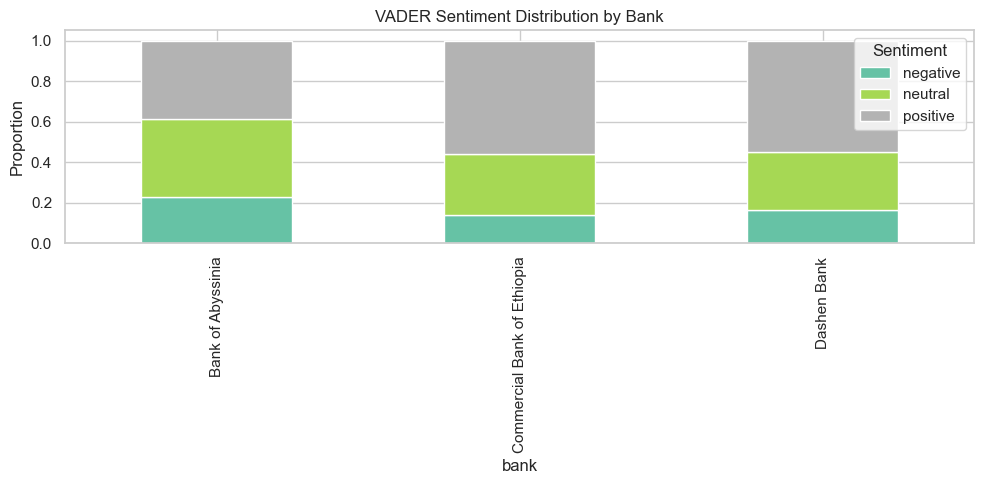

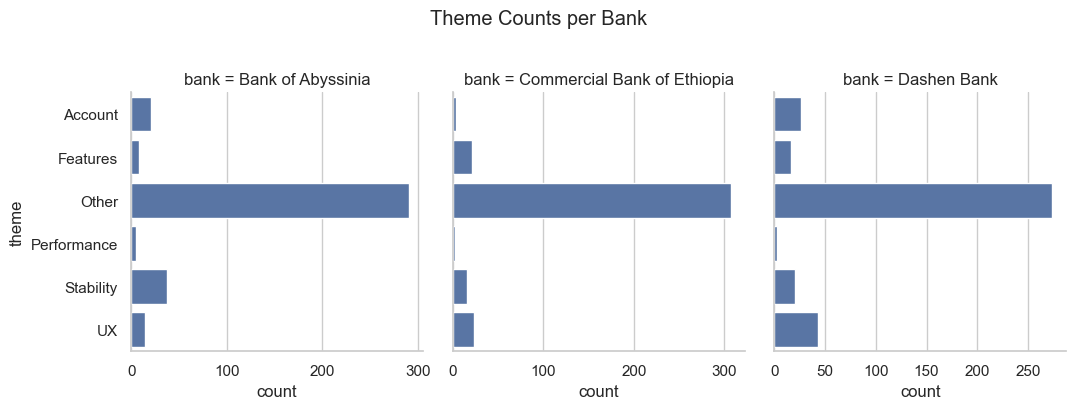

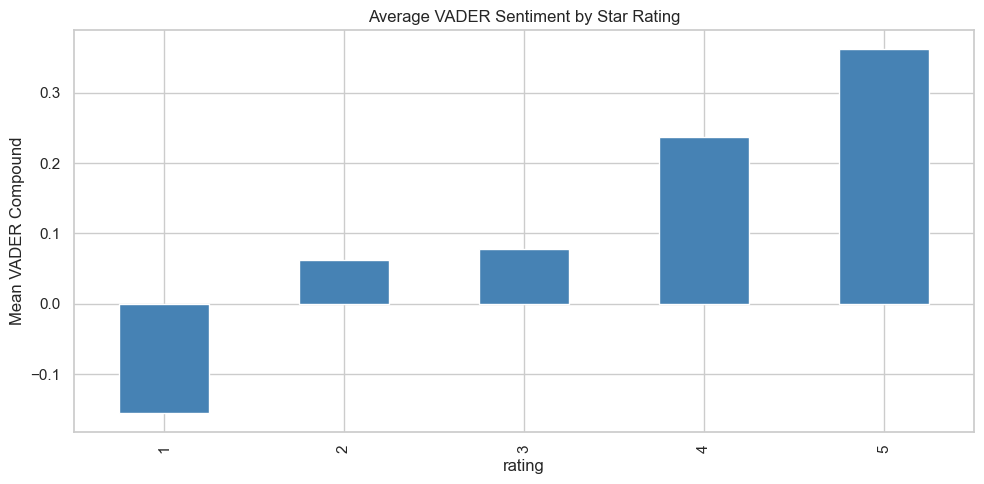

In [24]:
# Visualizations: sentiment distribution and top themes
# 1) Sentiment distribution by bank (VADER)
vader_pivot = df.pivot_table(index='bank', columns='vader_label', values='review', aggfunc='count', fill_value=0)
vader_pivot_norm = vader_pivot.div(vader_pivot.sum(axis=1), axis=0)
vader_pivot_norm.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('VADER Sentiment Distribution by Bank')
plt.ylabel('Proportion')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

# 2) Top themes per bank (bar chart)
theme_counts = df.groupby(['bank', 'theme']).size().reset_index(name='count')
import seaborn as sns
g = sns.catplot(data=theme_counts, x='count', y='theme', col='bank', kind='bar', sharex=False, height=4, aspect=0.9)
g.fig.suptitle('Theme Counts per Bank', y=1.02)
plt.tight_layout()
plt.show()

# 3) Sentiment by rating
df.groupby('rating')['vader_compound'].mean().plot(kind='bar', color='steelblue')
plt.title('Average VADER Sentiment by Star Rating')
plt.ylabel('Mean VADER Compound')
plt.tight_layout()
plt.show()

In [25]:
# output schema required by the brief
if 'transformer_score' not in df.columns: df['transformer_score'] = np.nan
if 'transformer_label' not in df.columns: df['transformer_label'] = None
if 'review_id' not in df.columns: df['review_id'] = [f'rev_{i+1:05d}' for i in range(len(df))]

df['sentiment_score'] = df['transformer_score'].where(df['transformer_score'].notna(), df['vader_compound'])
df['sentiment_label'] = df['transformer_label'].str.lower().where(df['transformer_label'].notna(), df['vader_label'])
df['review_text'] = df['review']
df['identified_theme'] = df['theme']
df_out = df[['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme']].copy()

out_dir = os.path.join('data', 'processed')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'fintech_sentiment_analysis_results.csv')
df_out.to_csv(out_path, index=False)
print('Saved analysis CSV to:', out_path)
print('Output shape:', df_out.shape)
df_out.head()

Saved analysis CSV to: data\processed\fintech_sentiment_analysis_results.csv
Output shape: (1135, 5)


,review_id,review_text,sentiment_label,sentiment_score,identified_theme
0,rev_00001,Good,positive,0.999816,Other
1,rev_00002,🤙🏼🤙🏼,negative,-0.697057,Other
2,rev_00003,worst,negative,-0.999802,Other
3,rev_00004,this app very full,positive,0.997449,Other
4,rev_00005,good apps,positive,0.999861,Other
